# Sequential GMM Thresholding for Cell Cycle Staging

This notebook demonstrates the `SequentialGMM` class from the `cc_mapping` package, which enables **iterative refinement** of cell populations through sequential thresholding operations.

---

## Overview

Sequential thresholding allows you to progressively refine cell populations:
- Start with a broad classification (e.g., Low vs High)
- Refine specific subpopulations using additional features
- Track the complete refinement history and metadata

---

## Cell Cycle Staging Workflow

We'll perform complete cell cycle staging in three steps:
1. **pRB**: Separate G0 (quiescent) from cycling cells (G1/S/G2/M)
2. **p21**: Separate M phase from G1/S/G2
3. **DNA content**: Split G1/S/G2 into individual phases

---

## Setup and Data Loading

In [ ]:
from pathlib import Path
from urllib.request import urlretrieve

import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from cc_mapping.thresholding import SequentialGMM

%matplotlib inline

In [2]:
url = "https://zenodo.org/records/4525425/files/control_manifold_allfeatures.csv?download=1"

cwd = Path.cwd()
download_path = cwd / "data" / "control_manifold_allfeatures.csv"

if not download_path.parent.exists():
    download_path.parent.mkdir(parents=True)
    urlretrieve(url, download_path)

In [3]:
# Create results directory structure for saving figures
results_dir = cwd / "results"
sequential_results_dir = results_dir / "sequential"

# Create directories if they don't exist
results_dir.mkdir(exist_ok=True)
sequential_results_dir.mkdir(exist_ok=True)

print(f"Results directory created at: {results_dir}")
print(f"Sequential results directory: {sequential_results_dir}")

Results directory created at: c:\Users\dap182\Documents\git\cc_mapping\notebooks\results
Sequential results directory: c:\Users\dap182\Documents\git\cc_mapping\notebooks\results\sequential


In [4]:
# Load and convert to AnnData
csv = pd.read_csv(download_path, index_col=0, low_memory=False)
csv.index = csv.index.astype(str)

adata = ad.AnnData(
    X=csv.values[:,:-10].astype(np.float32),
)
adata.var_names = csv.columns.values[:-10]

print(f"Dataset: {adata.n_obs} cells x {adata.n_vars} features")
print(f"\nFeatures we'll use:")
print(f"  - pRB (nuc median): Initial G0 vs cycling split")
print(f"  - pp21 (nuc median): Separate M phase")
print(f"  - Int_Intg_DNA_nuc: Split G1/S/G2")

Dataset: 6797 cells x 289 features

Features we'll use:
  - pRB (nuc median): Initial G0 vs cycling split
  - pp21 (nuc median): Separate M phase
  - Int_Intg_DNA_nuc: Split G1/S/G2


### Filter Missing Values

GMM thresholding requires removing cells with NaN values in the features we'll use.

In [5]:
# Define the features we'll use for sequential thresholding
features_to_use = [
    'pRB (nuc median)', 
    'pp21 (nuc median)', 
    'Int_Intg_DNA_nuc'
]

# Get feature indices
feature_indices = [list(adata.var_names).index(f) for f in features_to_use]

# Find cells with NaN values in any of these features
cells_with_nan = np.any(np.isnan(adata.X[:, feature_indices]), axis=1)

print(f"Cells with NaN values: {cells_with_nan.sum()} / {adata.n_obs}")

# Filter out cells with NaN values
if cells_with_nan.sum() > 0:
    adata = adata[~cells_with_nan, :].copy()
    print(f"After filtering: {adata.n_obs} cells remaining")
else:
    print("No cells with NaN values found!")

Cells with NaN values: 1 / 6797
After filtering: 6796 cells remaining


---

## Initial Thresholding: G0 vs G1/S/G2/M

Use **pRB** (phosphorylated Retinoblastoma protein) to separate quiescent G0 cells from actively cycling cells.

In [6]:
# Initialize the sequential thresholding object
gmm_kwargs = {
    'init_params': 'k-means++', 
    'n_init': 10, 
    'max_iter': 1000, 
    'random_state': 42
}

seq_gmm = SequentialGMM(
    adata=adata,
    thresholding_events_key='sequential_gmm_thresholding',
    gmm_kwargs=gmm_kwargs
)

print("Sequential thresholding object initialized!")
print("Metadata will be stored in: adata.uns['sequential_gmm_thresholding']")

Sequential thresholding object initialized!
Metadata will be stored in: adata.uns['sequential_gmm_thresholding']


### Exploratory Visualization

Explore the data distribution before thresholding to decide on parameters:

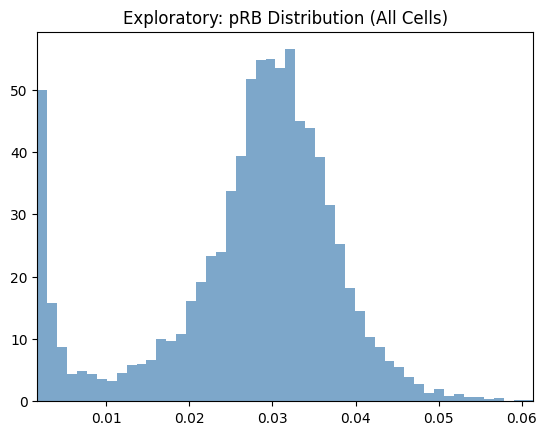

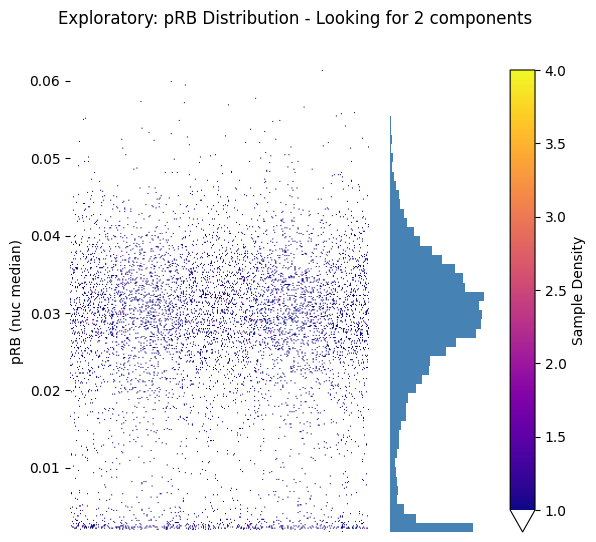

In [7]:
# Explore pRB distribution across all cells
seq_gmm.plot_feature_distribution_exploratory(
    feature='pRB (nuc median)',
    hist_kwargs={'bins': 50, 'color': 'steelblue', 'alpha': 0.7},
)
plt.title('Exploratory: pRB Distribution (All Cells)')
plt.show()

# Or use the strip plot version for better visualization
fig, (ax_strip, ax_hist) = seq_gmm.plot_feature_strip_plot_exploratory(
    feature='pRB (nuc median)',
    hist_kwargs={'bins': 50, 'color': 'steelblue'},
    scatter_density=True
)
plt.suptitle('Exploratory: pRB Distribution - Looking for 2 components')
plt.show()

In [8]:
# Perform initial thresholding: G0 vs G1/S/G2/M
seq_gmm.threshold_entire_dataset(
    feature='pRB (nuc median)',
    label_obs_save_str='cell_cycle_phase',  # This column will store our labels
    n_components=2,
    ordered_labels=['G0', 'G1/S/G2/M'],
    operation_name='initial_pRB_split'
)

print("Initial thresholding complete!")
print(f"\nLabel distribution:")
print(seq_gmm.adata.obs['cell_cycle_phase'].value_counts())

Initial thresholding complete!

Label distribution:
cell_cycle_phase
G1/S/G2/M    6101
G0            695
Name: count, dtype: int64


### Visualize Results

Figure saved to: c:\Users\dap182\Documents\git\cc_mapping\notebooks\results\sequential\step1_pRB_split.png


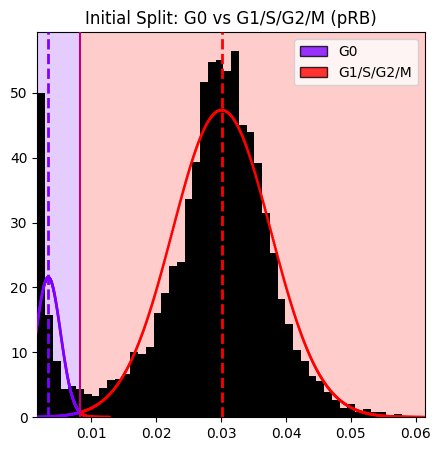

In [9]:
hist_kwargs = {
    'bins': 50, 'color': "black"}

# Plot histogram with decision boundaries
seq_gmm.plot_hist_distribution_with_boundaries(
    operation_name='initial_pRB_split',
    resolution=1000,
    num_std=5,
    hist_kwargs=hist_kwargs,
    save_path=sequential_results_dir / 'step1_pRB_split.png'  # Optional: save the figure
)
plt.title('Initial Split: G0 vs G1/S/G2/M (pRB)')
plt.show()

**Note:** The histogram shows the pRB distribution at the time of this operation. After subsequent refinements (M, G1, S, G2), only cells that still have the original labels (G0 or G1/S/G2/M) are shown in the histogram.

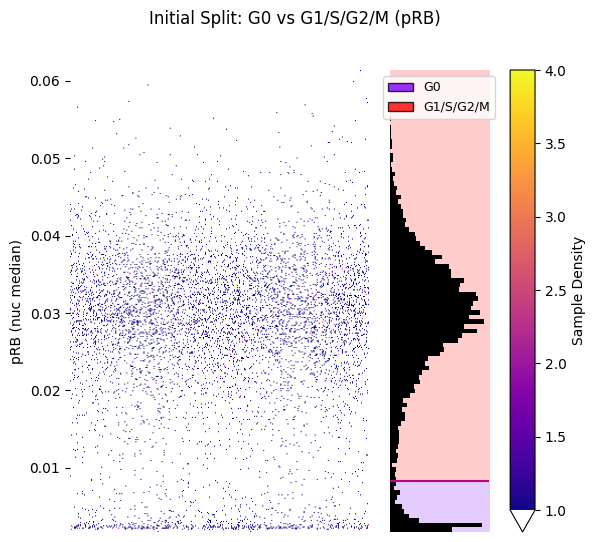

In [10]:
# Strip plot with labels
hist_kwargs = {"bins": 100, 'color': 'black'}
seq_gmm.plot_strip_plot_histogram_with_decision_boundaries(
    operation_name='initial_pRB_split',
    hist_kwargs=hist_kwargs,
    scatter_density=True
)
plt.suptitle('Initial Split: G0 vs G1/S/G2/M (pRB)')
plt.show()

---

## First Refinement: Separate M Phase

Use **p21** to refine the G1/S/G2/M population and separate M phase cells (p21 is typically low in M phase).

### Exploratory Visualization

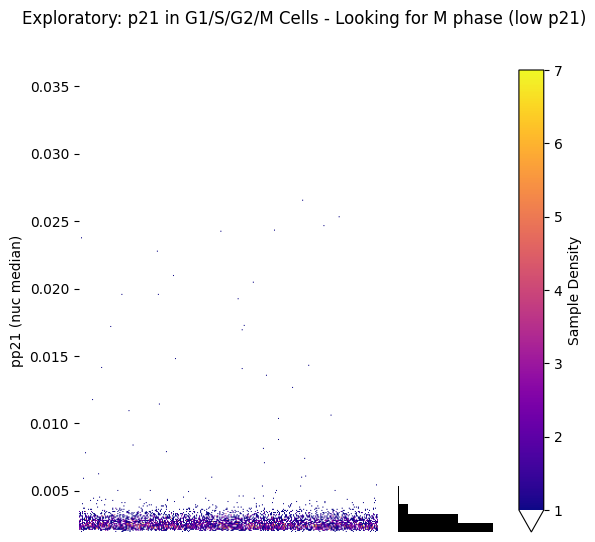

In [11]:
# Explore p21 distribution in G1/S/G2/M cells only (not G0)
fig, (ax_strip, ax_hist) = seq_gmm.plot_feature_strip_plot_exploratory(
    feature='pp21 (nuc median)',
    obs_label='cell_cycle_phase',
    value_to_subset='G1/S/G2/M',  # Only look at cycling cells
    hist_kwargs={'bins': 50, 'color': 'black'},
    scatter_density=True
)
plt.suptitle('Exploratory: p21 in G1/S/G2/M Cells - Looking for M phase (low p21)')
plt.show()

# This helps us see if 2 components are appropriate and where the boundary might be

In [12]:
# Refine G1/S/G2/M population to separate M phase
seq_gmm.refine_labels_with_gmm(
    feature='pp21 (nuc median)',
    obs_label='cell_cycle_phase',
    value_to_refine='G1/S/G2/M',
    n_components=2,
    ordered_labels=['G1/S/G2','M'],
    operation_name='separate_M_phase',
    duplicate_labels=False
)

print("First refinement complete!")
print(f"\nUpdated label distribution:")
print(seq_gmm.adata.obs['cell_cycle_phase'].value_counts())

First refinement complete!

Updated label distribution:
cell_cycle_phase
G1/S/G2      6067
G0            695
M              34
G1/S/G2/M       0
Name: count, dtype: int64


### Visualize Results

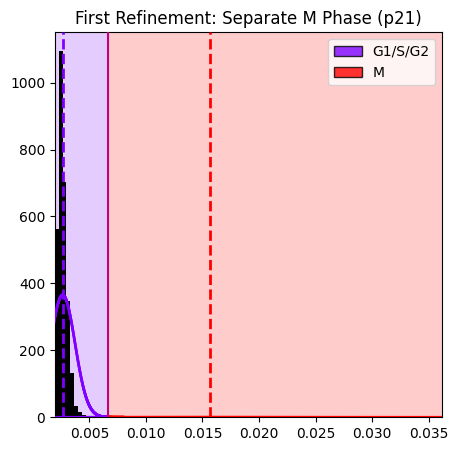

In [13]:
# Plot the M phase separation
seq_gmm.plot_hist_distribution_with_boundaries(
    operation_name='separate_M_phase',
)
plt.title('First Refinement: Separate M Phase (p21)')
plt.show()

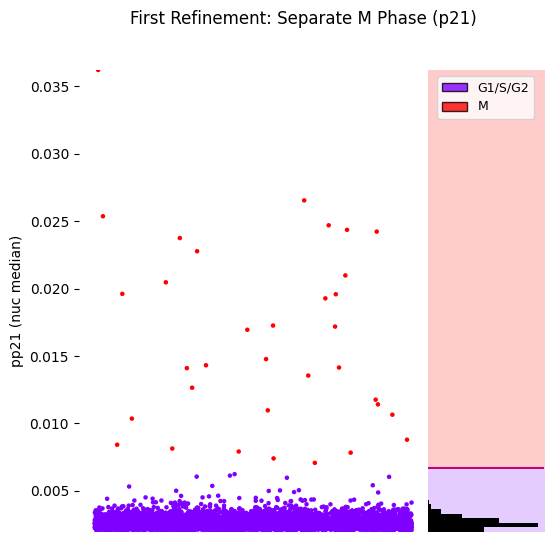

In [14]:
# Strip plot
hist_kwargs = {"bins": 100, 'color': 'black'}
seq_gmm.plot_strip_plot_histogram_with_decision_boundaries(
    operation_name='separate_M_phase',
    hist_kwargs=hist_kwargs,
    scatter_density=False,
    title='First Refinement: Separate M Phase (p21)'
)
plt.show()

---

## Second Refinement: G1, S, G2

Use **DNA content** (Int_Intg_DNA_nuc) to refine the G1/S/G2 population into individual phases. DNA content increases through these phases: G1 (2n) → S (2n-4n) → G2 (4n).

### Exploratory Visualization

Explore DNA content distribution to decide between automatic GMM or manual thresholds:

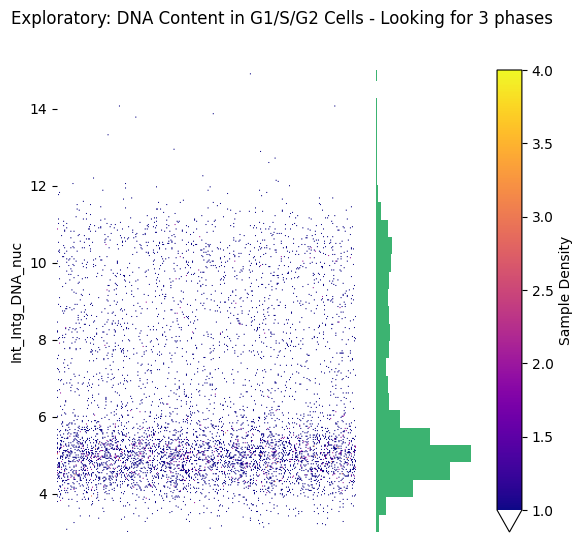

In [15]:
# Explore DNA content distribution in G1/S/G2 cells only
fig, (ax_strip, ax_hist) = seq_gmm.plot_feature_strip_plot_exploratory(
    feature='Int_Intg_DNA_nuc',
    obs_label='cell_cycle_phase',
    value_to_subset='G1/S/G2',  # Only look at G1/S/G2 cells (not M or G0)
    hist_kwargs={'bins': 50, 'color': 'mediumseagreen'},
    scatter_density=True,
    x_axis_limits=(3, 15)
)
plt.suptitle('Exploratory: DNA Content in G1/S/G2 Cells - Looking for 3 phases')
plt.show()

# From this plot, we can:
# - See if 3 components are appropriate
# - Identify potential manual threshold locations (e.g., around 6 and 9)
# - Check for outliers or overlapping distributions

In [16]:
# Refine G1/S/G2 population to separate individual phases
seq_gmm.refine_labels_with_manual_thresholds(
    feature='Int_Intg_DNA_nuc',
    obs_label='cell_cycle_phase',
    value_to_refine='G1/S/G2',
    manual_thresholds=[6, 9],
    ordered_labels=['G1', 'S', 'G2'],
    operation_name='separate_G1_S_G2',
)

print("Second refinement complete!")
print(f"\nFinal label distribution:")
print(seq_gmm.adata.obs['cell_cycle_phase'].value_counts())

Second refinement complete!

Final label distribution:
cell_cycle_phase
G1           3968
S            1151
G2            948
G0            695
M              34
G1/S/G2         0
G1/S/G2/M       0
Name: count, dtype: int64


### Visualize Results

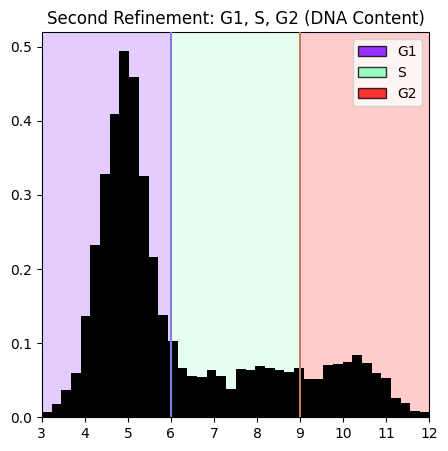

In [17]:
hist_kwargs = {"bins": 100, 'color': 'black'}
# Plot the G1/S/G2 separation
seq_gmm.plot_hist_distribution_with_boundaries(
    operation_name='separate_G1_S_G2',
    hist_kwargs=hist_kwargs,
    x_axis_limits=(3, 12)
)
plt.title('Second Refinement: G1, S, G2 (DNA Content)')
plt.show()

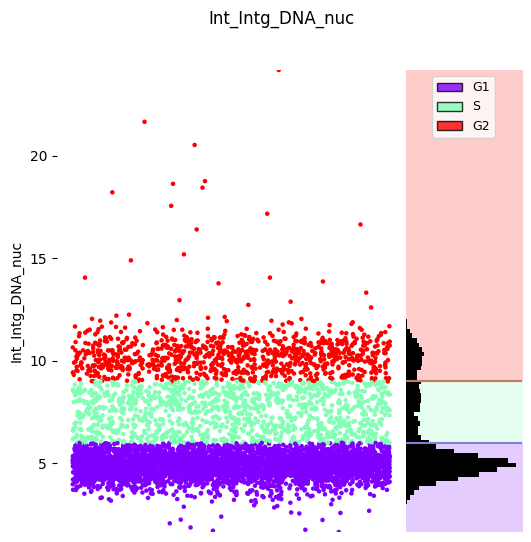

In [18]:
# Strip plot
hist_kwargs = {"bins": 100, 'color': 'black'}
seq_gmm.plot_strip_plot_histogram_with_decision_boundaries(
    operation_name='separate_G1_S_G2',
    hist_kwargs=hist_kwargs,
    scatter_density=False
)
plt.show()

In [19]:
adata_final = seq_gmm.return_adata()

---

## Utility Functions

### Generate Thresholding Report

In [20]:
# Generate a text report using the method from the base class
report = seq_gmm.generate_thresholding_report(
    output_format='text'
)
print(report)

Thresholding Report

1. initial_pRB_split (Standard Thresholding)
--------------------------------------------
   Feature: pRB (nuc median)
   Layer: None
   Obs column: cell_cycle_phase
   Components: 2
   Thresholds: [0.0083]
   Labels: ['G0', 'G1/S/G2/M']
   Cell counts: G1/S/G2/M=6101, G0=695

2. separate_M_phase (Refinement) of cell_cycle_phase
----------------------------------------------------
   Feature: pp21 (nuc median)
   Layer: None
   Obs column: cell_cycle_phase
   Components: 2
   Thresholds: [0.0067]
   Labels: ['G1/S/G2', 'M']
   Refined from: ['G1/S/G2/M']
   Cell counts: G1/S/G2=6067, M=34

3. separate_G1_S_G2 (Refinement) of cell_cycle_phase
----------------------------------------------------
   Feature: Int_Intg_DNA_nuc
   Layer: None
   Obs column: cell_cycle_phase
   Components: N/A (manual thresholds)
   Thresholds: [6.0000, 9.0000]
   Labels: ['G1', 'S', 'G2']
   Refined from: ['G1/S/G2']
   Cell counts: G1=3968, S=1151, G2=948

Total operations: 3
Operation 

Or as a DataFrame for further analysis:

In [21]:
# Generate a DataFrame report
report_df = seq_gmm.generate_thresholding_report(
    output_format='dataframe'
)
display(report_df)

,Operation,Type,Feature,Layer,Obs Label,Components,Thresholds,Labels,Parent,Refined From,Total Cells
0,1. initial_pRB_split,standard,pRB (nuc median),None,cell_cycle_phase,2,0.0083,"G0, G1/S/G2/M",None,N/A,6796
1,2. separate_M_phase,refinement,pp21 (nuc median),None,cell_cycle_phase,2,0.0067,"G1/S/G2, M",cell_cycle_phase,G1/S/G2/M,6101
2,3. separate_G1_S_G2,refinement_manual,Int_Intg_DNA_nuc,None,cell_cycle_phase,N/A (manual thresholds),"6.0000, 9.0000","G1, S, G2",cell_cycle_phase,G1/S/G2,6067


### Boolean Label Combination

Combine categorical labels with boolean operators (AND, OR, XOR) for advanced filtering. This example identifies cells that are both in a specific treatment group AND in certain cell cycle phases.

In [22]:
from cc_mapping.utils import create_boolean_label_combination

# Create synthetic treatment labels for demonstration
np.random.seed(42)
n_cells = len(adata_final)
adata_final.obs['treatment'] = pd.Categorical(
    np.random.choice(['Drug_A', 'Drug_B', 'Control'], size=n_cells)
)

# Combine two categorical labels using boolean operators
# Note: Parameter names are obs_key_1, match_values_1, output_obs_key, true_label, false_label
adata_final = create_boolean_label_combination(
    adata_final,
    obs_key_1='treatment',
    match_values_1=['Control'],
    obs_key_2='cell_cycle_phase',
    match_values_2=['G2', 'M'],  # Combine G2 and M phases
    operator='AND',  # Find cells that are BOTH Control AND in G2 or M phase
    output_obs_key='control_and_G2M',
    true_label='control_G2M',
    false_label='other',
    overwrite=False  # Default: raises error if output_obs_key already exists
)

print("Combined label distribution:")
print(adata_final.obs['control_and_G2M'].value_counts())

Combined label distribution:
control_and_G2M
other          6499
control_G2M     297
Name: count, dtype: int64
